In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr 
import tqdm
from direvo_functions import *
import scripts.empirical_landscape_decay_curves as eld
import pickle as pkl
import matplotlib.pyplot as plt

In [3]:
from Bio.Align import substitution_matrices

# 1. Load the matrix
blosum62 = substitution_matrices.load("BLOSUM62")

# 2. Access specific scores (Example: Tryptophan 'W' to Cysteine 'C')
# Note: These are log-odds scores, NOT probabilities yet.
score = blosum62['W', 'C']  
print(f"Score for W -> C: {score}")  # Output: -2 (Unfavorable)

# 3. Print the whole matrix to console
print(blosum62)

# 4. If you need the list of Amino Acids in the correct order:
print(blosum62.alphabet)

Score for W -> C: -2.0
#  Matrix made by matblas from blosum62.iij
#  * column uses minimum score
#  BLOSUM Clustered Scoring Matrix in 1/2 Bit Units
#  Blocks Database = /data/blocks_5.0/blocks.dat
#  Cluster Percentage: >= 62
#  Entropy =   0.6979, Expected =  -0.5209
     A    R    N    D    C    Q    E    G    H    I    L    K    M    F    P    S    T    W    Y    V    B    Z    X    *
A  4.0 -1.0 -2.0 -2.0  0.0 -1.0 -1.0  0.0 -2.0 -1.0 -1.0 -1.0 -1.0 -2.0 -1.0  1.0  0.0 -3.0 -2.0  0.0 -2.0 -1.0  0.0 -4.0
R -1.0  5.0  0.0 -2.0 -3.0  1.0  0.0 -2.0  0.0 -3.0 -2.0  2.0 -1.0 -3.0 -2.0 -1.0 -1.0 -3.0 -2.0 -3.0 -1.0  0.0 -1.0 -4.0
N -2.0  0.0  6.0  1.0 -3.0  0.0  0.0  0.0  1.0 -3.0 -3.0  0.0 -2.0 -3.0 -2.0  1.0  0.0 -4.0 -2.0 -3.0  3.0  0.0 -1.0 -4.0
D -2.0 -2.0  1.0  6.0 -3.0  0.0  2.0 -1.0 -1.0 -3.0 -4.0 -1.0 -3.0 -3.0 -1.0  0.0 -1.0 -4.0 -3.0 -3.0  4.0  1.0 -1.0 -4.0
C  0.0 -3.0 -3.0 -3.0  9.0 -3.0 -4.0 -3.0 -3.0 -1.0 -1.0 -3.0 -1.0 -2.0 -3.0 -1.0 -1.0 -2.0 -2.0 -1.0 -3.0 -3.0 -2.0 -4

In [4]:
biosum_arr = np.array(blosum62)[:20, :20]
normed_biosum = np.exp(biosum_arr) / np.sum(np.exp(biosum_arr), axis=1, keepdims=True)
no_diag_bisum = biosum_arr - np.identity(20) * 1000
normed_no_diag_biosum = np.exp(no_diag_bisum) / np.sum(np.exp(no_diag_bisum), axis=1, keepdims=True)

In [19]:
mutty_func = build_custom_mutation_function(1.0, normed_no_diag_biosum)

In [20]:
mutation_chance = 1.0
blosum_probs = jnp.array(normed_no_diag_biosum)
A = 20

def mutation_function(rng, pop):
    r1, r2 = jr.split(rng, 2)
    pshape = pop.shape
    has_mutation = jr.bernoulli(r1, mutation_chance, pshape)

    flat_pop = pop.flatten()
    pop_size = flat_pop.shape[0]

    def mutate_amino_acid(rng, aa):
        return jr.choice(rng, jnp.arange(A), p=blosum_probs[aa])

    mutate_amino_acid_vmap = jax.vmap(mutate_amino_acid)

    flat_mutated_pop = mutate_amino_acid_vmap(jr.split(r2, pop_size), flat_pop)
    mutated_pop = flat_mutated_pop.reshape(pshape)

    return jnp.where(has_mutation, mutated_pop, pop)

In [21]:
mutation_function(jr.PRNGKey(0), jnp.array([[0, 1, 2]]))

Array([[11, 12,  3]], dtype=int32)

In [22]:
mutty_func(jr.PRNGKey(0), jnp.array([[0, 1, 2]]))

Array([[11, 12,  3]], dtype=int32)

In [8]:
biosum_arr.shape

(20, 20)

In [9]:
np.save("other_data/blosum62_probs.npy", normed_biosum)
np.save("other_data/blosum62_no_diag_probs.npy", normed_no_diag_biosum)

In [10]:
normed_biosum.diagonal()

array([0.84015339, 0.90541306, 0.96423586, 0.96518325, 0.99950292,
       0.88130807, 0.86401254, 0.98839653, 0.99479734, 0.6213919 ,
       0.72336012, 0.8930516 , 0.88964591, 0.93629789, 0.99670718,
       0.77643683, 0.93643795, 0.99980478, 0.96656429, 0.64843957])

In [11]:
((blosum62 - blosum62.T) != 0).any()

np.False_

In [12]:
with open('plot_data/subsampling_empirical_estimates.pkl', 'rb') as f:
    num_samples_totest, results_means, results_stds, data_names = pkl.load(f)

In [13]:
with open("/home/seb/code/phd/SLIDE/SLIDE_data/empirical_decay_curves/decay_curves_tev_m0.1_popsize517_multistart_2000_uniform.pkl", "rb") as f:
    trb_decay = pkl.load(f)

In [14]:
trb_decay.shape

(20, 100, 10, 25)

In [15]:
num_samples_totest

array([  10,   19,   37,   71,  138,  268,  517, 1000])

In [16]:
with open("landscape_arrays/GB1_landscape_array.pkl", "rb") as f:
    GB1 = pkl.load(f)

with open("landscape_arrays/TrpB_landscape_array.pkl", "rb") as f:
    TrpB = pkl.load(f)

with open("landscape_arrays/TEV_landscape_array.pkl", "rb") as f:
    TEV = pkl.load(f)

with open("landscape_arrays/E3_landscape_array.pkl", "rb") as f:
    E3 = pkl.load(f)

/tmp/ipykernel_183303/3596651816.py:2: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  GB1 = pkl.load(f)
/tmp/ipykernel_183303/3596651816.py:11: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  E3 = pkl.load(f)


In [17]:

gb1_d = eld.generate_decay_curve(GB1, 0.025, p=2500, vmap_width=1000, num_reps = 10)

In [28]:
at_gc = 0.221  # A->G, T->C
gc_at = 0.408  # G->A, C->T

# Transversions
at_ta = 0.067  # A->T, T->A
gc_ta = 0.110  # G->T, C->A
at_cg = 0.078  # A->C, T->G
gc_cg = 0.125  # G->C, C->G

# Initialize 4x4 matrix with zeros
human_mat = np.zeros((4, 4))

# Map values to (Row, Col) -> (Start, End)
# A Row (Index 0)
human_mat[0, 1] = at_cg  # A -> C
human_mat[0, 2] = at_gc  # A -> G
human_mat[0, 3] = at_ta  # A -> T

# C Row (Index 1)
human_mat[1, 0] = gc_ta  # C -> A (symmetric to G->T, denoted as GC>TA)
human_mat[1, 2] = gc_cg  # C -> G
human_mat[1, 3] = gc_at  # C -> T

# G Row (Index 2)
human_mat[2, 0] = gc_at  # G -> A
human_mat[2, 1] = gc_cg  # G -> C
human_mat[2, 3] = gc_ta  # G -> T

# T Row (Index 3)
human_mat[3, 0] = at_ta  # T -> A
human_mat[3, 1] = at_gc  # T -> C
human_mat[3, 2] = at_cg  # T -> G

aas = ['A', 'C', 'G', 'T']

In [33]:
human_mat

normed_human_mat = human_mat / human_mat.sum(axis=1, keepdims=True)

np.save("other_data/normed_human_codon_matrix.npy", normed_human_mat)
np.save("other_data/human_codon_matrix.npy", human_mat)

In [32]:
normed_human_mat[0].sum()

np.float64(1.0)

In [36]:
mutty_func_h = build_custom_mutation_function(1.0, normed_human_mat)

In [37]:
mutty_func_h(jr.PRNGKey(0), jnp.array([[0, 1, 2]]))

Array([[2, 3, 0]], dtype=int32)

In [57]:
import selection_function_library as slct
def directedEvolution(
    rng,
    selection_strategy,
    selection_params,

    landscape_function = None,
    mutation_function = None,
    popsize=100,
    mut_chance=0.01,
    num_steps=50,
    num_reps=10,
    define_i_pop=None,
    pre_optimisation_steps=0,
    average=True,
):

    r1, r2, r3 = jr.split(rng, 3)

    # Get initial population.
    if define_i_pop == None:
        i_pop = jnp.array([jr.randint(r1, (N,), 0, 2)] * popsize)
    else:
        i_pop = define_i_pop

    # Function for evaluating fitness.
    if landscape_function is None:
        raise ValueError("landscape_function must be provided")
    if mutation_function is None:
        raise ValueError("mutation_function must be provided")

    # Define selection function.
    selection_function = build_selection_function(selection_strategy, selection_params)

    if pre_optimisation_steps != 0:

        pre_op_selection_function = build_selection_function(
            slct.base_chance_threshold_select, {"base_chance": 0.0, "threshold": 0.95}
        )

        pre_op = run_directed_evolution(
            r3,
            i_pop=i_pop,
            selection_function=pre_op_selection_function,
            mutation_function=mutation_function,
            fitness_function=landscape_function,
            num_steps=pre_optimisation_steps,
        )[1]

        i_pop = pre_op["pop"][-1]

    # Bringing it all together.
    vmapped_run = jax.jit(
        jax.vmap(
            lambda r: run_directed_evolution(
                r,
                i_pop,
                selection_function,
                mutation_function,
                fitness_function=landscape_function,
                num_steps=num_steps,
            )[1]
        )
    )

    # The array of seeds we will take as input.
    rng_seeds = jr.split(r3, num_reps)
    results = vmapped_run(rng_seeds)

    return results


def generate_decay_curve(ld_func, m, p=2500, vmap_width = 100, num_reps = 100, rng =None, ld_shape = None, mut_func = None):

    if rng is None:
        rng = jax.random.PRNGKey(42)
    
    if ld_shape is None:
        raise ValueError("ld_shape must be provided")
    
    ## generate random starts
    # if ld.shape == (20, 20, 20, 20):
    #     all_starts = uniform_start_locs(ld, num = num_reps * vmap_width).reshape( num_reps,vmap_width, 4)
    # else:
    #     all_starts = uniform_start_locs(ld, num = num_reps * vmap_width).reshape(num_reps, vmap_width, 3)
    rng_starts, rng = jr.split(rng)
    minvals = jnp.array([0] * len(ld_shape))
    maxvals = jnp.array(ld_shape)
    all_starts = jr.randint(rng_starts, (num_reps ,  vmap_width, len(ld_shape)), minvals, maxvals)


    def single_rep(rng_start):
        rng, start = rng_start
        params = {"threshold": 0.0, "base_chance": 1.0}
        run = directedEvolution(
            rng,
            selection_strategy=slct.base_chance_threshold_select,
            selection_params=params,
            popsize=int(p),
            mut_chance=m,
            num_steps=25,
            num_reps=10,
            pre_optimisation_steps=10,
            define_i_pop=jnp.array([start] * int(p)),
            landscape_function=ld_func,
            mutation_function=mut_func,
            average=False,
        )

        # split_results.append(run['fitness'].max(axis=2).mean(axis=0)[-1])
        return run["fitness"].mean(axis=-1)

    rng_seeds = jr.split(rng, num_reps * vmap_width)
    rng_seeds = rng_seeds.reshape(num_reps, vmap_width, 2)
    results = jax.lax.map(jax.vmap(single_rep), (rng_seeds, all_starts)) 

    return results



In [100]:
import scripts.empirical_landscape_decay_curves as eld
import ruggedness_functions as rf
rng = jr.PRNGKey(42)
N = 4
A = 20
example_rmf = eld.build_rough_mount_fuji_landscape_function(rng, N, slope_scale=1.0, noise_scale=2.0)
mutation_function = build_mutation_function(0.1, A)
codon_rmg = eld.convert_landscape_function_to_codon(example_rmf, stop_codon_strategy="another_amino_acid", stop_codon_value=-0.0)
codon_mutation_function = build_custom_mutation_function(0.1/3, normed_human_mat)

decay_curve = generate_decay_curve(example_rmf, 0.3, p=2500, vmap_width=100, num_reps = 4, ld_shape = (A,)*N, mut_func=mutation_function)

decay_curve_codon = generate_decay_curve(codon_rmg, 0.3, p=2500, vmap_width=100, num_reps = 4, ld_shape = (4,)*(3*N), mut_func=codon_mutation_function)


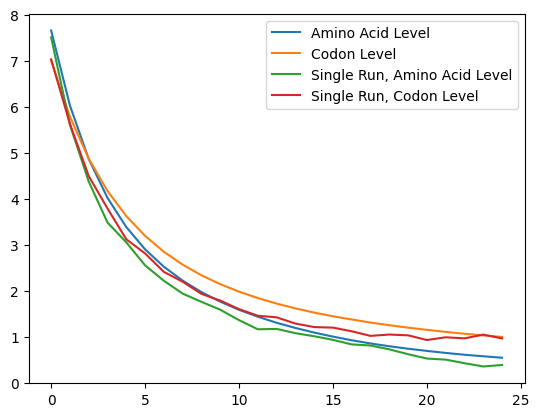

In [115]:
decay_curve_mean = decay_curve.mean(axis = (0,1,2))
decay_curve_codon_mean = decay_curve_codon.mean(axis = (0,1,2))

plt.plot(decay_curve_mean, label="Amino Acid Level")
plt.plot(decay_curve_codon_mean*0.95, label="Codon Level")
plt.plot(decay_curve[0,0,0], label="Single Run, Amino Acid Level")
plt.plot(decay_curve_codon[0,1,8]*0.95, label="Single Run, Codon Level")
plt.legend()

In [102]:
def get_single_decay_rate(decay_data, mut=0.1, num_steps=25):

    num_params = 1
    decay_data = decay_data / decay_data[0]

    if isinstance(mut, (int, float, complex)) or jnp.ndim(mut) == 0:
        steps = np.linspace(0, num_steps - 1, num_steps)
    else:
        steps = mut

    if mut is None:
        mut = np.arange(len(decay_data))  # Default steps

    asymptote_guess = decay_data[-3:].mean() / decay_data[0]
    lower_bound = min(0.0, asymptote_guess - 0.2)
    upper_bound = max(1.1, asymptote_guess + 0.2)

    init_guess = np.concatenate([np.linspace(0.1, 0.9, num_params), [asymptote_guess]])
    lbounds = [0.0] * num_params + [lower_bound]
    ubounds = [2.0] * num_params + [upper_bound]

    model = lambda x, *params: model_function(x, *params, mut=mut)

    params, _ = curve_fit(
        model,
        steps,
        decay_data,
        p0=init_guess,
        maxfev=9000,
        ftol=1e-4,
        xtol=1e-5,
        bounds=(lbounds, ubounds),
    )
    mean_params = np.mean(params[:-1])
    fitted_constant = params[-1]  # The second returned parameter

    return mean_params, fitted_constant  # Return full params for plotting

In [103]:
get_single_decay_rate(decay_curve[0,0,0], mut = 0.1*4)

(np.float64(0.6451232921012973), np.float64(0.08676785618643454))

In [111]:
get_single_decay_rate(decay_curve_codon[122,10,8], mut = 0.1*4)

(np.float64(0.5128755068284625), np.float64(0.09660376997915394))

In [104]:
decay_curve.std(axis = (0,1,2))

Array([0.68500394, 0.66038465, 0.64620453, 0.62087333, 0.58432853,
       0.5445382 , 0.49976888, 0.45941913, 0.41885364, 0.38085124,
       0.34555906, 0.3124122 , 0.28426686, 0.25848785, 0.23469849,
       0.21388121, 0.19670375, 0.18003921, 0.16759665, 0.15660328,
       0.14511643, 0.13652442, 0.12912412, 0.12269787, 0.11708048],      dtype=float32)

In [54]:
(0,) * len(ld_shape)

(0, 0, 0, 0)

In [55]:
ld_shape

(20, 20, 20, 20)

In [ ]:
generate_decay_curve

In [40]:
def uniform_start_locs(ld, num=10000):
    flat_ld = ld.flatten()
    flat_indexes = np.round(np.linspace(0, flat_ld.shape[0] - 1, num)).astype(int)
    indexes = np.array([np.unravel_index(i, ld.shape) for i in flat_indexes])
    return indexes

In [41]:
uniform_start_locs(ld = jnp.zeros((20,20,20,20)), num = 10)

array([[ 0,  0,  0,  0],
       [ 2,  4,  8, 18],
       [ 4,  8, 17, 15],
       [ 6, 13,  6, 13],
       [ 8, 17, 15, 11],
       [11,  2,  4,  8],
       [13,  6, 13,  6],
       [15, 11,  2,  4],
       [17, 15, 11,  1],
       [19, 19, 19, 19]])

In [42]:
jr.randint(jr.PRNGKey(0), (10,5), jnp.arange(5),  jnp.arange(5) * 2)

Array([[0, 1, 2, 4, 7],
       [0, 1, 3, 3, 7],
       [0, 1, 2, 3, 7],
       [0, 1, 2, 3, 5],
       [0, 1, 2, 4, 5],
       [0, 1, 3, 3, 4],
       [0, 1, 3, 4, 5],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 5],
       [0, 1, 2, 3, 7]], dtype=int32)